In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ahmedmohamed2003/retail-store-sales-dirty-for-data-cleaning")

print("Path to dataset files:", path)



100%|██████████| 221k/221k [00:00<00:00, 859kB/s]

Extracting files...
Path to dataset files: C:\Users\nadis\.cache\kagglehub\datasets\ahmedmohamed2003\retail-store-sales-dirty-for-data-cleaning\versions\1


In [2]:
import pandas as pd
df = pd.read_csv('retail_store_sales.csv')

In [ ]:
#df.info()
df['Item'] = df['Item'].fillna('Unknown')
# Fill missing values in 'Item' column with 'Unknown'
#print(df.isna().sum())
#df.info()
print(df.duplicated().sum())
print(df['Transaction ID'].duplicated().sum())
# every transaction id is unique

df['Transaction Date'] = pd.to_datetime(df['Transaction Date'], errors = 'coerce')


missing = df['Quantity'].isna() != df['Total Spent'].isna()
print(missing.sum())

df_clean = df.dropna(subset=['Quantity', 'Total Spent']).copy()

df_clean['Calculating Spent'] = df_clean['Quantity']*df_clean['Price Per Unit']

df_clean['Error'] = (df_clean['Calculating Spent'] - df_clean['Total Spent']).abs()


display(
    df_clean[
        ['Price Per Unit', 'Quantity', 'Total Spent', 'Calculating Spent', 'Error']
    ].head()
)



0
0
0


,Price Per Unit,Quantity,Total Spent,Calculating Spent,Error
0,18.5,10.0,185.0,185.0,0.0
1,29.0,9.0,261.0,261.0,0.0
2,21.5,2.0,43.0,43.0,0.0
3,27.5,9.0,247.5,247.5,0.0
4,12.5,7.0,87.5,87.5,0.0


12550


In [4]:
df.info()
df.shape 
df.describe()


<class 'pandas.DataFrame'>
RangeIndex: 12575 entries, 0 to 12574
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    12575 non-null  str           
 1   Customer ID       12575 non-null  str           
 2   Category          12575 non-null  str           
 3   Item              12575 non-null  str           
 4   Price Per Unit    11966 non-null  float64       
 5   Quantity          11971 non-null  float64       
 6   Total Spent       11971 non-null  float64       
 7   Payment Method    12575 non-null  str           
 8   Location          12575 non-null  str           
 9   Transaction Date  12575 non-null  datetime64[us]
 10  Discount Applied  8376 non-null   object        
dtypes: datetime64[us](1), float64(3), object(1), str(6)
memory usage: 1.1+ MB


,Price Per Unit,Quantity,Total Spent,Transaction Date
count,11966.000000,11971.000000,11971.000000,12575
mean,23.365912,5.536380,129.652577,2023-07-12 20:23:41.105367
min,5.000000,1.000000,5.000000,2022-01-01 00:00:00
25%,14.000000,3.000000,51.000000,2022-09-30 00:00:00
50%,23.000000,6.000000,108.500000,2023-07-13 00:00:00
75%,33.500000,8.000000,192.000000,2024-04-24 00:00:00
max,41.000000,10.000000,410.000000,2025-01-18 00:00:00
std,10.743519,2.857883,94.750697,NaN


-160.5 403.5
108.5


C:\Users\nadis\AppData\Local\Temp\ipykernel_22072\3695398227.py:10: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  mp.boxplot(df_clean['Total Spent'], vert=False)


Text(0.5, 1.0, 'Outliers in Total Spent')

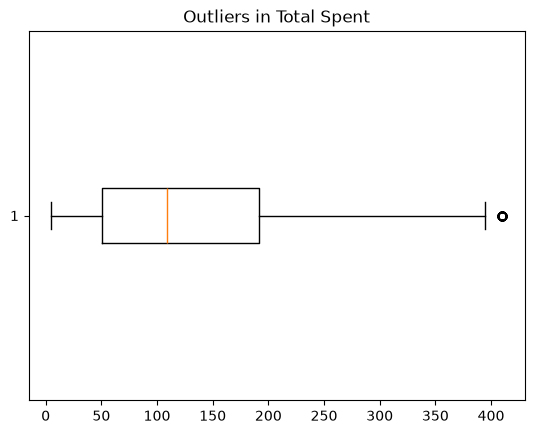

In [17]:
import matplotlib.pyplot as mp
Iqr = df_clean['Total Spent'].quantile(0.75) - df_clean['Total Spent'].quantile(0.25)
lower_bound = df_clean['Total Spent'].quantile(0.25) - (1.5 * Iqr)
upper_bound = df_clean['Total Spent'].quantile(0.75) + (1.5 * Iqr)
print(lower_bound, upper_bound)
print(df['Total Spent'].median())

outliers = df_clean[(df_clean['Total Spent'] < lower_bound) | (df_clean['Total Spent'] > upper_bound)]
mp.figure()
mp.boxplot(df_clean['Total Spent'], vert=False)
mp.title('Outliers in Total Spent')




In [6]:
df_clean.info

<bound method DataFrame.info of       Transaction ID Customer ID       Category          Item  Price Per Unit  \
0        TXN_6867343     CUST_09     Patisserie   Item_10_PAT            18.5   
1        TXN_3731986     CUST_22  Milk Products  Item_17_MILK            29.0   
2        TXN_9303719     CUST_02       Butchers   Item_12_BUT            21.5   
3        TXN_9458126     CUST_06      Beverages   Item_16_BEV            27.5   
4        TXN_4575373     CUST_05           Food   Item_6_FOOD            12.5   
...              ...         ...            ...           ...             ...   
12570    TXN_9347481     CUST_18     Patisserie   Item_23_PAT            38.0   
12571    TXN_4009414     CUST_03      Beverages    Item_2_BEV             6.5   
12572    TXN_5306010     CUST_11       Butchers    Item_7_BUT            14.0   
12573    TXN_5167298     CUST_04      Furniture    Item_7_FUR            14.0   
12574    TXN_2407494     CUST_23           Food   Item_9_FOOD            17.0